In [1]:
# import pandas as pd

# df = pd.read_csv('database.csv')


# Q, FR, alpha, beta = 100, 60, 90, 0
# point_A_Te = 315  # User-defined A

# # Filter for condition
# df_sel = df[(df['Q[W]'] == Q) & (df['FR[%]'] == FR) & (df['alpha'] == alpha) & (df['beta'] == beta)]

# # Filter for Te range (optional, can be adjusted)
# te_min, te_max = 315, 370
# df_filtered = df_sel[(df_sel['Te_mean[K]'] >= te_min) & (df_sel['Te_mean[K]'] <= te_max)].copy()

# df_filtered = df_filtered.sort_values('Te_mean[K]')
# Te = df_filtered['Te_mean[K]'].values
# Tc = df_filtered['Tc_mean[K]'].values

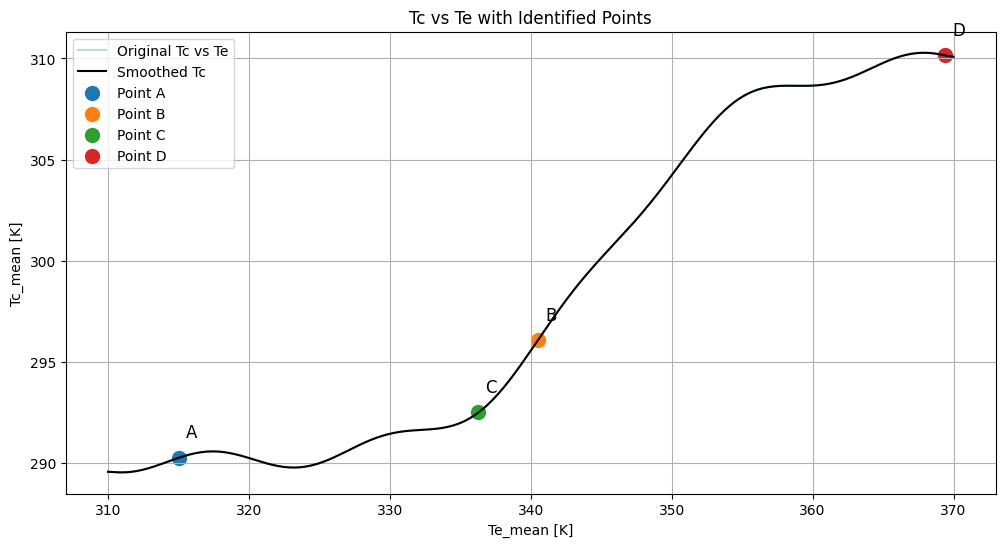

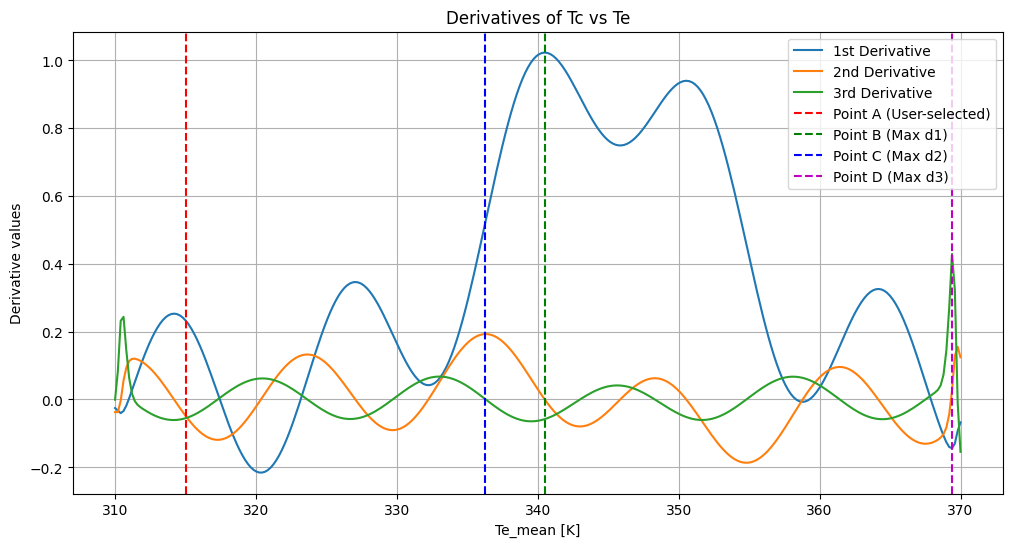

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# ---- Step 1: Sample Data (Replace with your actual data) ----
# Example: Te_mean from 310K to 370K
Te = np.linspace(310, 370, 300)
# Simulate a sample Tc curve (similar shape to your image)
Tc = 300 + 10 * np.tanh(0.1*(Te - 345)) + 0.5 * np.sin(0.5 * Te)

# ---- Step 2: Smooth Data (Optional but recommended) ----
Tc_smooth = gaussian_filter1d(Tc, sigma=2)

# ---- Step 3: Compute Derivatives ----
d1 = np.gradient(Tc_smooth, Te)           # First derivative
d2 = np.gradient(d1, Te)                  # Second derivative
d3 = np.gradient(d2, Te)                  # Third derivative

# ---- Step 4: Identify Points ----
# Point A: manually chosen
point_A_Te = 315
point_A_idx = np.argmin(np.abs(Te - point_A_Te))

# Point B: Max slope
point_B_idx = np.argmax(d1)

# Point C: Max curvature
point_C_idx = np.argmax(d2)

# Point D: Max third derivative
point_D_idx = np.argmax(d3)

# ---- Plotting ----
plt.figure(figsize=(12, 6))
plt.plot(Te, Tc, label='Original Tc vs Te', alpha=0.3)
plt.plot(Te, Tc_smooth, label='Smoothed Tc', color='black')

# Mark points A, B, C, D
for idx, label in zip([point_A_idx, point_B_idx, point_C_idx, point_D_idx], ['A', 'B', 'C', 'D']):
    plt.scatter(Te[idx], Tc_smooth[idx], label=f'Point {label}', s=100)
    plt.text(Te[idx]+0.5, Tc_smooth[idx]+1, f'{label}', fontsize=12)

plt.xlabel('Te_mean [K]')
plt.ylabel('Tc_mean [K]')
plt.title('Tc vs Te with Identified Points')
plt.legend()
plt.grid(True)
plt.show()

# ---- Optional: Plot Derivatives ----
plt.figure(figsize=(12, 6))
plt.plot(Te, d1, label='1st Derivative')
plt.plot(Te, d2, label='2nd Derivative')
plt.plot(Te, d3, label='3rd Derivative')
plt.axvline(Te[point_A_idx], color='r', linestyle='--', label='Point A (User-selected)')
plt.axvline(Te[point_B_idx], color='g', linestyle='--', label='Point B (Max d1)')
plt.axvline(Te[point_C_idx], color='b', linestyle='--', label='Point C (Max d2)')
plt.axvline(Te[point_D_idx], color='m', linestyle='--', label='Point D (Max d3)')
plt.xlabel('Te_mean [K]')
plt.ylabel('Derivative values')
plt.title('Derivatives of Tc vs Te')
plt.legend()
plt.grid(True)
plt.show()


Analysis for Q=80W, FR=60%, α=90°, β=0°
Te range: 320-390K
Data points before outlier removal: 2486
Data points after Tc outlier removal: 2486
Data points after P outlier removal: 2486

POLYNOMIAL DEGREE OPTIMIZATION

🔧 Optimizing polynomial degree for Tc vs Te:
🔍 Optimizing polynomial degree (testing degrees 3-20)...
  📊 Degree optimization results:
    • Best RMSE: degree 3 (RMSE: 147.3811)
    • Best AIC: degree 20 (AIC: 5631.52)
    • Best BIC: degree 20 (BIC: 5753.70)
    • 🎯 Optimal (composite): degree 20 (RMSE: 795.0031, R²: 0.9675)
    ⚠️ High degree (20) detected - potential overfitting risk

🔍 Analyzing Tc vs Te relationship:
  Data points: 2486
  Polynomial degree: 20
  📊 Fit Quality: RMSE = 2.8993, R² = 0.9712
  ✅ Good fit: Acceptable R² (0.971)

CRITICAL POINTS ANALYSIS
Point A: Te=322.4K, Y=299.500
  d1=-0.0279, d2=0.6285, d3=-0.4731
  → Minimum value point (automatic selection)
Point B: Te=357.5K, Y=325.392
  d1=4.2505, d2=0.0091, d3=-0.2147
  → Maximum slope point
  → d

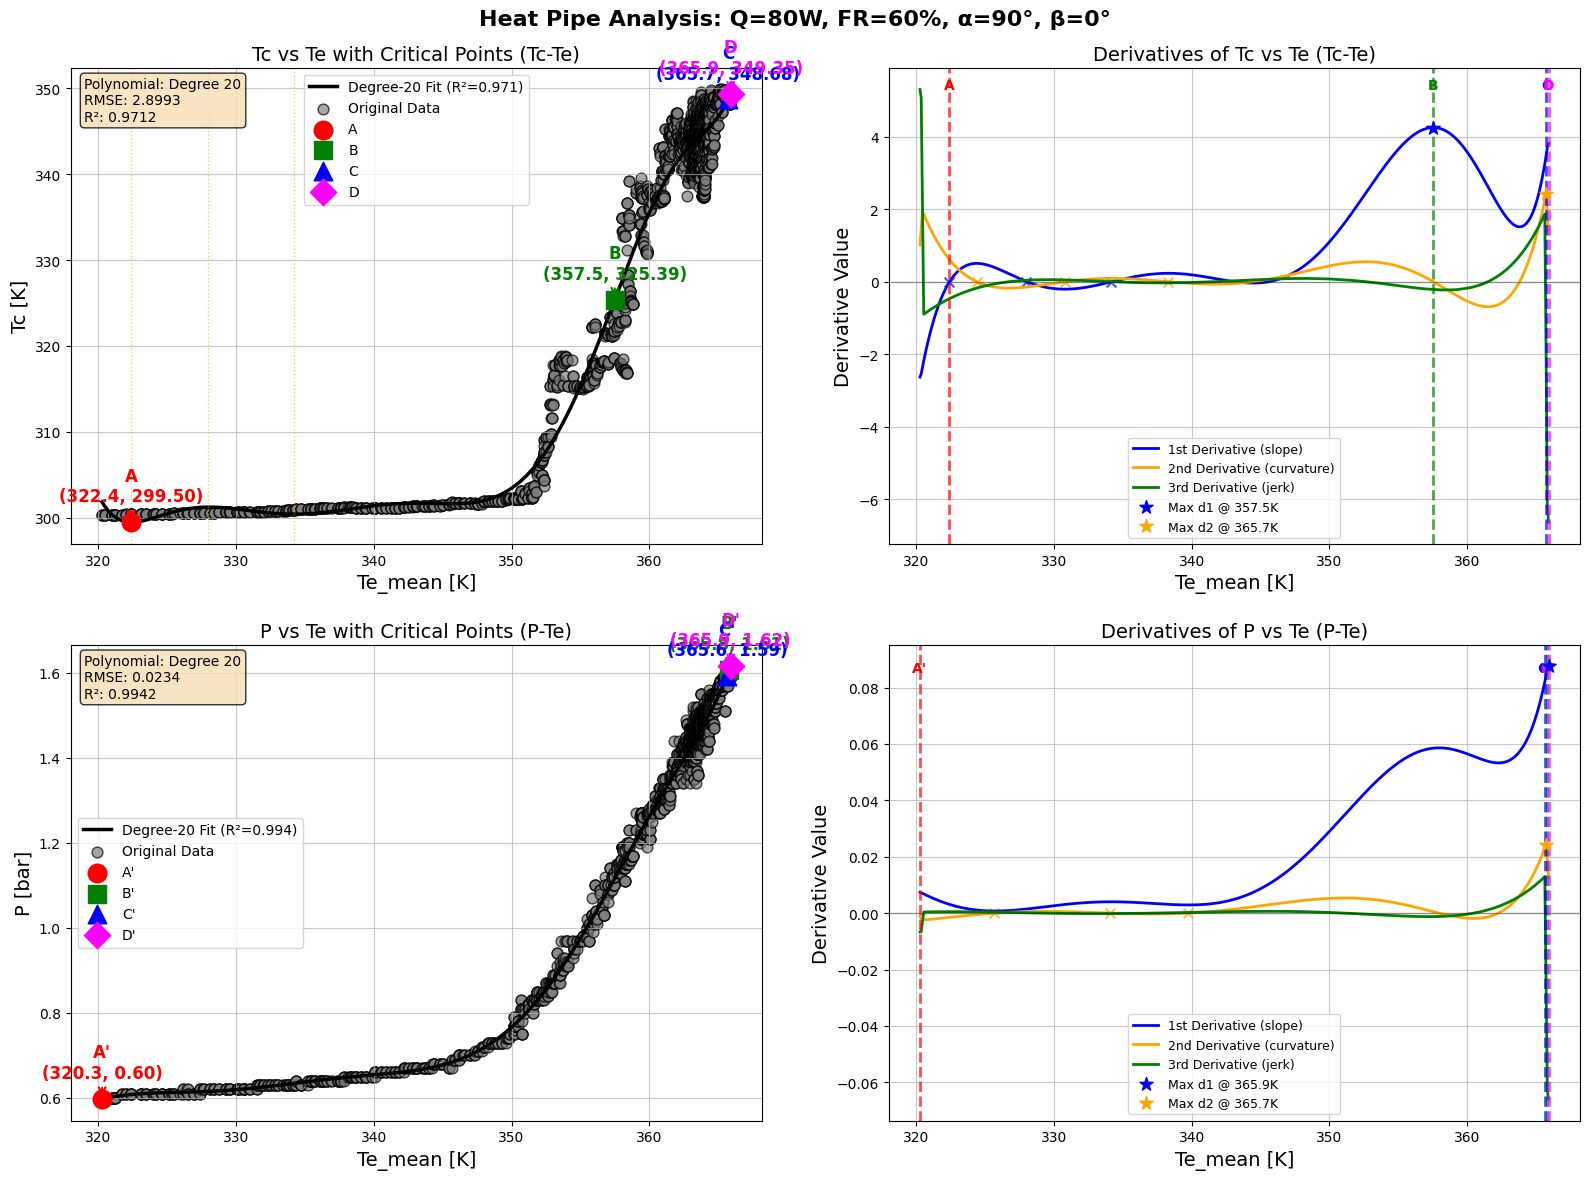


COMPREHENSIVE CRITICAL POINTS SUMMARY WITH VALIDATION

Tc vs Te (Temperature Analysis):
-------------------------------

Point A: Te = 322.4K, Tc = 299.500 K
  Derivatives: d1=-0.0279, d2=0.6285, d3=-0.4731

Point B: Te = 357.5K, Tc = 325.392 K
  Derivatives: d1=4.2505, d2=0.0091, d3=-0.2147
  📈 Condition Check: d1 efficiency = 100.0% of max, |d2| = 0.0091
  ✅ EXCELLENT: Optimal steep slope with minimal curvature

Point C: Te = 365.7K, Tc = 348.677 K
  Derivatives: d1=3.4642, d2=2.4278, d3=-1.8777
  📊 Condition Check: d2 efficiency = 100.0% of max, |d3| = 1.8777
  ✅ GOOD: High curvature region well-captured

Point D: Te = 365.9K, Tc = 349.353 K
  Derivatives: d1=3.8136, d2=1.3036, d3=-6.6317

🎯 Reference Global Maxima:
  Maximum slope: Te = 357.5K (d1 = 4.2505)
  Maximum curvature: Te = 365.7K (d2 = 2.4278)

📍 Point Positioning Analysis:
  Point B vs max d1 location: ΔTe = 0.0K
  Point C vs max d2 location: ΔTe = 0.0K
  ✅ Point B closely aligned with maximum slope
  ✅ Point C closely 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy.stats import zscore
from scipy.optimize import minimize_scalar
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

def optimize_polynomial_degree(Te, Y, max_degree=15, min_degree=5, cv_folds=5):
    """
    Optimize polynomial degree based on RMSE using cross-validation and information criteria
    
    Parameters:
    -----------
    Te : array
        Independent variable (temperature)
    Y : array
        Dependent variable (Tc or P)
    max_degree : int, default=15
        Maximum polynomial degree to test
    min_degree : int, default=2
        Minimum polynomial degree to test
    cv_folds : int, default=5
        Number of cross-validation folds
    
    Returns:
    --------
    dict : Optimization results with best degree and metrics
    """
    
    degrees = range(min_degree, min(max_degree + 1, len(Te) // 3))  # Ensure enough data points
    rmse_scores = []
    aic_scores = []
    bic_scores = []
    r2_scores = []
    
    # Reshape for sklearn
    Te_reshaped = Te.reshape(-1, 1)
    
    print(f"🔍 Optimizing polynomial degree (testing degrees {min_degree}-{max(degrees)})...")
    
    for degree in degrees:
        try:
            # Create polynomial pipeline
            poly_pipeline = Pipeline([
                ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
                ('linear', LinearRegression())
            ])
            
            # Cross-validation RMSE
            cv_scores = cross_val_score(poly_pipeline, Te_reshaped, Y, 
                                       cv=min(cv_folds, len(Te)//2), 
                                       scoring='neg_root_mean_squared_error')
            rmse_cv = -cv_scores.mean()
            rmse_scores.append(rmse_cv)
            
            # Fit full model for AIC/BIC calculation
            poly_pipeline.fit(Te_reshaped, Y)
            Y_pred = poly_pipeline.predict(Te_reshaped)
            
            # Calculate metrics
            mse = mean_squared_error(Y, Y_pred)
            n = len(Y)
            k = degree + 1  # Number of parameters
            
            # R²
            ss_res = np.sum((Y - Y_pred) ** 2)
            ss_tot = np.sum((Y - np.mean(Y)) ** 2)
            r2 = 1 - (ss_res / ss_tot)
            r2_scores.append(r2)
            
            # AIC and BIC (lower is better)
            aic = n * np.log(mse) + 2 * k
            bic = n * np.log(mse) + k * np.log(n)
            aic_scores.append(aic)
            bic_scores.append(bic)
            
        except Exception as e:
            print(f"  ⚠️ Error with degree {degree}: {str(e)}")
            rmse_scores.append(float('inf'))
            aic_scores.append(float('inf'))
            bic_scores.append(float('inf'))
            r2_scores.append(-float('inf'))
    
    # Convert to arrays for easier handling
    degrees = np.array(degrees)
    rmse_scores = np.array(rmse_scores)
    aic_scores = np.array(aic_scores)
    bic_scores = np.array(bic_scores)
    r2_scores = np.array(r2_scores)
    
    # Find optimal degrees using different criteria
    valid_idx = np.isfinite(rmse_scores)
    
    if not np.any(valid_idx):
        print("  ❌ No valid polynomial fits found, using default degree 5")
        return {'optimal_degree': 5, 'method': 'default', 'rmse': float('inf')}
    
    best_rmse_idx = np.argmin(rmse_scores[valid_idx])
    best_aic_idx = np.argmin(aic_scores[valid_idx])
    best_bic_idx = np.argmin(bic_scores[valid_idx])
    
    best_rmse_degree = degrees[valid_idx][best_rmse_idx]
    best_aic_degree = degrees[valid_idx][best_aic_idx]
    best_bic_degree = degrees[valid_idx][best_bic_idx]
    
    # Composite scoring: balance between fit quality and complexity
    # Normalize scores to [0,1] and create composite score
    rmse_norm = (rmse_scores - np.min(rmse_scores[valid_idx])) / (np.max(rmse_scores[valid_idx]) - np.min(rmse_scores[valid_idx]) + 1e-10)
    aic_norm = (aic_scores - np.min(aic_scores[valid_idx])) / (np.max(aic_scores[valid_idx]) - np.min(aic_scores[valid_idx]) + 1e-10)
    
    # Composite score: 60% RMSE + 40% AIC (balances fit quality and complexity)
    composite_scores = 0.6 * rmse_norm + 0.4 * aic_norm
    best_composite_idx = np.argmin(composite_scores[valid_idx])
    best_composite_degree = degrees[valid_idx][best_composite_idx]
    
    # Choose the optimal degree (prefer composite score for balanced approach)
    optimal_degree = best_composite_degree
    optimal_rmse = rmse_scores[valid_idx][best_composite_idx]
    optimal_r2 = r2_scores[valid_idx][best_composite_idx]
    
    print(f"  📊 Degree optimization results:")
    print(f"    • Best RMSE: degree {best_rmse_degree} (RMSE: {rmse_scores[valid_idx][best_rmse_idx]:.4f})")
    print(f"    • Best AIC: degree {best_aic_degree} (AIC: {aic_scores[valid_idx][best_aic_idx]:.2f})")
    print(f"    • Best BIC: degree {best_bic_degree} (BIC: {bic_scores[valid_idx][best_bic_idx]:.2f})")
    print(f"    • 🎯 Optimal (composite): degree {optimal_degree} (RMSE: {optimal_rmse:.4f}, R²: {optimal_r2:.4f})")
    
    # Check for overfitting signs
    if optimal_degree > 10:
        print(f"    ⚠️ High degree ({optimal_degree}) detected - potential overfitting risk")
    elif optimal_degree <= 3:
        print(f"    ℹ️ Low degree ({optimal_degree}) selected - simple model")
    else:
        print(f"    ✅ Moderate degree ({optimal_degree}) - good balance")
    
    return {
        'optimal_degree': int(optimal_degree),
        'method': 'composite_score',
        'rmse': optimal_rmse,
        'r2': optimal_r2,
        'degrees_tested': degrees[valid_idx].tolist(),
        'rmse_scores': rmse_scores[valid_idx].tolist(),
        'aic_scores': aic_scores[valid_idx].tolist(),
        'bic_scores': bic_scores[valid_idx].tolist(),
        'best_rmse_degree': int(best_rmse_degree),
        'best_aic_degree': int(best_aic_degree),
        'best_bic_degree': int(best_bic_degree)
    }

def analyze_heat_pipe_data(csv_path, Q, FR, alpha, beta, te_min, te_max, 
                          point_A_Te=None, poly_deg='auto', outlier_threshold=2.5, 
                          max_poly_deg=15, min_poly_deg=2):
    """
    Comprehensive function to analyze heat pipe data for both Tc vs Te and P vs Te relationships
    
    Parameters:
    -----------
    csv_path : str
        Path to the CSV file containing the data
    Q, FR, alpha, beta : float
        Operating conditions for filtering
    te_min, te_max : float
        Temperature range for filtering
    point_A_Te : float, optional
        User-defined Te value for point A. If None, uses minimum function value
    poly_deg : int or 'auto', default='auto'
        Degree of polynomial for fitting. If 'auto', optimizes based on RMSE
    outlier_threshold : float, default=2.5
        Z-score threshold for outlier removal
    max_poly_deg : int, default=15
        Maximum polynomial degree to test when optimizing
    min_poly_deg : int, default=2
        Minimum polynomial degree to test when optimizing
    
    Returns:
    --------
    dict : Analysis results for both Tc and P relationships
    """
    
    # Load and filter data
    df = pd.read_csv(csv_path)
    
    # Filter for specific condition
    df_sel = df[(df['Q[W]'] == Q) & (df['FR[%]'] == FR) & 
                (df['alpha'] == alpha) & (df['beta'] == beta)]
    
    # Filter for Te range
    df_filtered = df_sel[(df_sel['Te_mean[K]'] >= te_min) & 
                        (df_sel['Te_mean[K]'] <= te_max)].copy()
    
    if df_filtered.empty:
        print("No data found for given condition and range.")
        return None
    
    print(f"Analysis for Q={Q}W, FR={FR}%, α={alpha}°, β={beta}°")
    print(f"Te range: {te_min}-{te_max}K")
    print(f"Data points before outlier removal: {len(df_filtered)}")
    
    # Remove outliers for both Tc and P
    df_tc_clean = df_filtered[np.abs(zscore(df_filtered['Tc_mean[K]'])) < outlier_threshold]
    df_p_clean = df_filtered[np.abs(zscore(df_filtered['P[bar]'])) < outlier_threshold]
    
    print(f"Data points after Tc outlier removal: {len(df_tc_clean)}")
    print(f"Data points after P outlier removal: {len(df_p_clean)}")
    
    results = {}
    
    # Determine polynomial degrees for each analysis
    print(f"\n{'='*60}")
    print("POLYNOMIAL DEGREE OPTIMIZATION")
    print(f"{'='*60}")
    
    tc_poly_deg = poly_deg
    p_poly_deg = poly_deg
    
    # Optimize polynomial degree for Tc analysis
    if len(df_tc_clean) > min_poly_deg:
        if poly_deg == 'auto':
            print(f"\n🔧 Optimizing polynomial degree for Tc vs Te:")
            Te_tc = df_tc_clean.sort_values('Te_mean[K]')['Te_mean[K]'].values
            Tc_tc = df_tc_clean.sort_values('Te_mean[K]')['Tc_mean[K]'].values
            tc_opt_result = optimize_polynomial_degree(Te_tc, Tc_tc, max_poly_deg, min_poly_deg)
            tc_poly_deg = tc_opt_result['optimal_degree']
        else:
            tc_poly_deg = poly_deg
            print(f"\n📌 Using fixed polynomial degree for Tc vs Te: {tc_poly_deg}")
            
        results['tc_analysis'] = _analyze_relationship(
            df_tc_clean, 'Tc_mean[K]', point_A_Te, tc_poly_deg, 'Tc', 'K', max_poly_deg, min_poly_deg
        )
    else:
        print(f"\n⚠️ Insufficient Tc data points ({len(df_tc_clean)}) for analysis")
    
    # Optimize polynomial degree for P analysis
    if len(df_p_clean) > min_poly_deg:
        if poly_deg == 'auto':
            print(f"\n🔧 Optimizing polynomial degree for P vs Te:")
            Te_p = df_p_clean.sort_values('Te_mean[K]')['Te_mean[K]'].values
            P_p = df_p_clean.sort_values('Te_mean[K]')['P[bar]'].values
            p_opt_result = optimize_polynomial_degree(Te_p, P_p, max_poly_deg, min_poly_deg)
            p_poly_deg = p_opt_result['optimal_degree']
        else:
            p_poly_deg = poly_deg
            print(f"\n📌 Using fixed polynomial degree for P vs Te: {p_poly_deg}")
            
        results['p_analysis'] = _analyze_relationship(
            df_p_clean, 'P[bar]', point_A_Te, p_poly_deg, 'P', 'bar', max_poly_deg, min_poly_deg
        )
    else:
        print(f"\n⚠️ Insufficient P data points ({len(df_p_clean)}) for analysis")
    
    # Create comprehensive plots
    _create_comprehensive_plots(results, Q, FR, alpha, beta)
    
    return results

def _analyze_relationship(df, y_col, point_A_Te, poly_deg, y_label, y_unit, max_poly_deg=15, min_poly_deg=2):
    """Helper function to analyze a specific relationship"""
    
    # Sort and extract data
    df_sorted = df.sort_values('Te_mean[K]')
    Te = df_sorted['Te_mean[K]'].values
    Y = df_sorted[y_col].values
    
    print(f"\n🔍 Analyzing {y_label} vs Te relationship:")
    print(f"  Data points: {len(Te)}")
    print(f"  Polynomial degree: {poly_deg}")
    
    # Polynomial fit with error handling
    try:
        coeffs = np.polyfit(Te, Y, deg=poly_deg)
        poly = np.poly1d(coeffs)
        Te_fine = np.linspace(Te.min(), Te.max(), 500)
        Y_fit = poly(Te_fine)
        
        # Calculate fit quality metrics
        Y_pred_original = poly(Te)
        rmse = np.sqrt(mean_squared_error(Y, Y_pred_original))
        ss_res = np.sum((Y - Y_pred_original) ** 2)
        ss_tot = np.sum((Y - np.mean(Y)) ** 2)
        r2 = 1 - (ss_res / ss_tot)
        
        print(f"  📊 Fit Quality: RMSE = {rmse:.4f}, R² = {r2:.4f}")
        
        if r2 < 0.8:
            print(f"  ⚠️ Warning: Low R² ({r2:.3f}) - consider different polynomial degree")
        elif r2 > 0.98:
            print(f"  🎯 Excellent fit: High R² ({r2:.3f})")
        else:
            print(f"  ✅ Good fit: Acceptable R² ({r2:.3f})")
        
    except Exception as e:
        print(f"  ❌ Polynomial fitting failed: {str(e)}")
        print(f"  🔄 Attempting fallback with degree 3...")
        
        try:
            poly_deg = 3
            coeffs = np.polyfit(Te, Y, deg=poly_deg)
            poly = np.poly1d(coeffs)
            Te_fine = np.linspace(Te.min(), Te.max(), 500)
            Y_fit = poly(Te_fine)
            
            Y_pred_original = poly(Te)
            rmse = np.sqrt(mean_squared_error(Y, Y_pred_original))
            ss_res = np.sum((Y - Y_pred_original) ** 2)
            ss_tot = np.sum((Y - np.mean(Y)) ** 2)
            r2 = 1 - (ss_res / ss_tot)
            
            print(f"  ✅ Fallback successful: degree 3, RMSE = {rmse:.4f}, R² = {r2:.4f}")
            
        except Exception as e2:
            print(f"  ❌ Fallback also failed: {str(e2)}")
            return None
    
    # Calculate derivatives
    d1 = np.gradient(Y_fit, Te_fine)  # 1st derivative
    d2 = np.gradient(d1, Te_fine)     # 2nd derivative
    d3 = np.gradient(d2, Te_fine)     # 3rd derivative
    
    # Identify critical points
    points = _identify_critical_points(Te_fine, Y_fit, d1, d2, d3, point_A_Te)
    
    return {
        'Te_original': Te,
        'Y_original': Y,
        'Te_fine': Te_fine,
        'Y_fit': Y_fit,
        'd1': d1,
        'd2': d2,
        'd3': d3,
        'points': points,
        'poly_coeffs': coeffs,
        'poly_degree': poly_deg,
        'rmse': rmse,
        'r2': r2,
        'y_label': y_label,
        'y_unit': y_unit
    }

def _find_zero_crossings(arr):
    """Find indices where the array crosses zero"""
    zero_crossings = []
    for i in range(len(arr) - 1):
        if arr[i] * arr[i + 1] < 0:  # Sign change indicates zero crossing
            zero_crossings.append(i)
    return np.array(zero_crossings)

def _identify_critical_points(Te_fine, Y_fit, d1, d2, d3, point_A_Te):
    """Identify critical points A, B, C, D based on derivative analysis"""
    
    # Point A: User-defined or minimum function value
    if point_A_Te is not None:
        point_A_idx = np.argmin(np.abs(Te_fine - point_A_Te))
    else:
        point_A_idx = np.argmin(Y_fit)
    
    # Point D: Maximum function value
    point_D_idx = np.argmax(Y_fit)
    
    # Ensure A comes before D
    if point_A_idx >= point_D_idx:
        point_A_idx = 0
    
    # Search range between A and D
    search_range = slice(point_A_idx + 1, point_D_idx)
    
    if search_range.start < search_range.stop:
        # Point B: Where 1st derivative is max AND 2nd derivative is close to zero
        # This represents the steepest slope where curvature is minimal
        
        # Find all local maxima of 1st derivative
        d1_search = d1[search_range]
        d2_search = d2[search_range]
        
        # Strategy 1: Find global max of d1, then check if d2 is reasonably small
        global_d1_max_idx = np.argmax(d1_search)
        global_d1_max_point = search_range.start + global_d1_max_idx
        
        # Strategy 2: Find candidates where both conditions are well satisfied
        d1_threshold = np.max(d1_search) * 0.75  # Within 75% of maximum
        d1_candidates = np.where(d1_search >= d1_threshold)[0]
        
        # Score each candidate using improved weighted scoring
        best_B_score = float('inf')
        point_B_idx = global_d1_max_point  # fallback to global max
        
        d1_max = np.max(d1_search)
        d2_max_abs = np.max(np.abs(d2_search))
        
        for candidate in d1_candidates:
            actual_idx = search_range.start + candidate
            d1_val = d1[actual_idx]
            d2_val = abs(d2[actual_idx])
            
            # Improved scoring: emphasize d1 maximization with d2 constraint
            d1_score = d1_val / d1_max  # [0,1] - higher is better
            d2_penalty = d2_val / (d2_max_abs + 1e-10)  # [0,~1] - lower is better
            
            # Combined score: 70% weight on d1, 30% penalty for high |d2|
            score = -(0.7 * d1_score) + (0.3 * d2_penalty)  # Lower is better
            
            if score < best_B_score:
                best_B_score = score
                point_B_idx = actual_idx
        
        # Point C: Where 2nd derivative is max AND 3rd derivative is close to zero
        # This represents maximum curvature where the rate of curvature change is minimal
        
        # Find all local maxima of 2nd derivative
        d3_search = d3[search_range]
        
        # Strategy 1: Find global max of d2, then check if d3 is reasonably small
        global_d2_max_idx = np.argmax(d2_search)
        global_d2_max_point = search_range.start + global_d2_max_idx
        
        # Strategy 2: Find candidates where both conditions are well satisfied
        d2_threshold = np.max(d2_search) * 0.75  # Within 75% of maximum
        d2_candidates = np.where(d2_search >= d2_threshold)[0]
        
        # Score each candidate using improved weighted scoring
        best_C_score = float('inf')
        point_C_idx = global_d2_max_point  # fallback to global max
        
        d2_max = np.max(d2_search)
        d3_max_abs = np.max(np.abs(d3_search))
        
        for candidate in d2_candidates:
            actual_idx = search_range.start + candidate
            d2_val = d2[actual_idx]
            d3_val = abs(d3[actual_idx])
            
            # Improved scoring: emphasize d2 maximization with d3 constraint
            d2_score = d2_val / d2_max  # [0,1] - higher is better
            d3_penalty = d3_val / (d3_max_abs + 1e-10)  # [0,~1] - lower is better
            
            # Combined score: 70% weight on d2, 30% penalty for high |d3|
            score = -(0.7 * d2_score) + (0.3 * d3_penalty)  # Lower is better
            
            if score < best_C_score:
                best_C_score = score
                point_C_idx = actual_idx
        
        # Additional analysis: Look for inflection points using 3rd derivative
        inflection_points = []
        zero_crossings_d3 = _find_zero_crossings(d3[search_range])
        for zc in zero_crossings_d3:
            inflection_points.append(search_range.start + zc)
        
        # Analyze derivative behavior for physical interpretation
        derivative_sum = np.abs(d1) + np.abs(d2) + np.abs(d3)
        min_derivative_sum_idx = np.argmin(derivative_sum[search_range])
        equilibrium_point = search_range.start + min_derivative_sum_idx
        
        # Ensure proper ordering: A < B < C < D
        # Allow flexibility since B and C represent different physical phenomena
        if point_B_idx > point_C_idx:
            # Check if the ordering should be maintained based on Te values
            # Sometimes C (max curvature) can come before B (max slope)
            pass  # Keep the calculated positions as they represent different physics
            
    else:
        # Fallback for edge cases
        point_B_idx = point_A_idx + (point_D_idx - point_A_idx) // 3
        point_C_idx = point_A_idx + 2 * (point_D_idx - point_A_idx) // 3
        inflection_points = []
        equilibrium_point = point_A_idx + (point_D_idx - point_A_idx) // 2
    
    points = {
        'A': point_A_idx,
        'B': point_B_idx, 
        'C': point_C_idx,
        'D': point_D_idx
    }
    
    # Print comprehensive analysis with improved scoring details
    print(f"\n{'='*50}")
    print(f"CRITICAL POINTS ANALYSIS")
    print(f"{'='*50}")
    
    for label, idx in points.items():
        y_val = Y_fit[idx]
        d1_val = d1[idx]
        d2_val = d2[idx]
        d3_val = d3[idx]
        print(f"Point {label}: Te={Te_fine[idx]:.1f}K, Y={y_val:.3f}")
        print(f"  d1={d1_val:.4f}, d2={d2_val:.4f}, d3={d3_val:.4f}")
        
        # Physical interpretation with enhanced condition validation
        if label == 'A':
            if point_A_Te is not None:
                print(f"  → User-defined starting point (Te={point_A_Te}K)")
            else:
                print(f"  → Minimum value point (automatic selection)")
        elif label == 'B':
            # Enhanced validation for point B
            d1_rank = np.sum(d1[search_range] <= d1_val) / len(d1[search_range]) * 100
            d2_abs_rank = np.sum(np.abs(d2[search_range]) >= abs(d2_val)) / len(d2[search_range]) * 100
            global_d1_max = np.max(d1[search_range])
            d1_percentage = (d1_val / global_d1_max) * 100 if global_d1_max > 0 else 0
            
            print(f"  → Maximum slope point")
            print(f"  → d1 achievement: {d1_percentage:.1f}% of global max (rank: {d1_rank:.1f}%)")
            print(f"  → |d2| minimization: {abs(d2_val):.4f} (rank from bottom: {100-d2_abs_rank:.1f}%)")
            print(f"  → Combined score: {-(0.7*d1_percentage/100) + (0.3*abs(d2_val)/np.max(np.abs(d2[search_range]))):.3f}")
            
            # Physical meaning
            if d1_percentage > 90:
                print(f"  → Physical interpretation: Optimal transition point (steep slope, low curvature)")
            elif d1_percentage > 75:
                print(f"  → Physical interpretation: Good transition point (high slope, controlled curvature)")
            else:
                print(f"  → Physical interpretation: Moderate transition point")
                
        elif label == 'C':
            # Enhanced validation for point C
            d2_rank = np.sum(d2[search_range] <= d2_val) / len(d2[search_range]) * 100
            d3_abs_rank = np.sum(np.abs(d3[search_range]) >= abs(d3_val)) / len(d3[search_range]) * 100
            global_d2_max = np.max(d2[search_range])
            d2_percentage = (d2_val / global_d2_max) * 100 if global_d2_max > 0 else 0
            
            print(f"  → Maximum curvature point")
            print(f"  → d2 achievement: {d2_percentage:.1f}% of global max (rank: {d2_rank:.1f}%)")
            print(f"  → |d3| minimization: {abs(d3_val):.4f} (rank from bottom: {100-d3_abs_rank:.1f}%)")
            print(f"  → Combined score: {-(0.7*d2_percentage/100) + (0.3*abs(d3_val)/np.max(np.abs(d3[search_range]))):.3f}")
            
            # Physical meaning
            if d2_percentage > 90:
                print(f"  → Physical interpretation: Peak curvature with stable rate (max acceleration)")
            elif d2_percentage > 75:
                print(f"  → Physical interpretation: High curvature with controlled rate change")
            else:
                print(f"  → Physical interpretation: Moderate curvature point")
                
        elif label == 'D':
            print(f"  → Maximum value point (system saturation/peak performance)")
    
    # Condition validation summary
    print(f"\nENHANCED CONDITION VALIDATION:")
    
    # Validate Point B conditions with detailed analysis
    B_idx = points['B']
    max_d1_in_range = np.max(d1[search_range])
    d1_at_B = d1[B_idx]
    d2_at_B = d2[B_idx]
    d1_efficiency = (d1_at_B / max_d1_in_range) * 100 if max_d1_in_range > 0 else 0
    
    print(f"Point B Performance Metrics:")
    print(f"  Primary condition (max d1): {d1_efficiency:.1f}% efficiency")
    print(f"  Secondary condition (d2≈0): |d2| = {abs(d2_at_B):.4f}")
    print(f"  Overall B-score: {-(0.7*d1_efficiency/100) + (0.3*abs(d2_at_B)/np.max(np.abs(d2[search_range]))):.3f}")
    
    if d1_efficiency > 95:
        print(f"  ✓ Excellent: Point B captures maximum slope effectively")
    elif d1_efficiency > 80:
        print(f"  ✓ Good: Point B represents high slope region well")
    else:
        print(f"  ⚠ Moderate: Point B balances slope and curvature constraints")
    
    # Validate Point C conditions with detailed analysis  
    C_idx = points['C']
    max_d2_in_range = np.max(d2[search_range])
    d2_at_C = d2[C_idx]
    d3_at_C = d3[C_idx]
    d2_efficiency = (d2_at_C / max_d2_in_range) * 100 if max_d2_in_range > 0 else 0
    
    print(f"Point C Performance Metrics:")
    print(f"  Primary condition (max d2): {d2_efficiency:.1f}% efficiency")
    print(f"  Secondary condition (d3≈0): |d3| = {abs(d3_at_C):.4f}")
    print(f"  Overall C-score: {-(0.7*d2_efficiency/100) + (0.3*abs(d3_at_C)/np.max(np.abs(d3[search_range]))):.3f}")
    
    if d2_efficiency > 95:
        print(f"  ✓ Excellent: Point C captures maximum curvature effectively")
    elif d2_efficiency > 80:
        print(f"  ✓ Good: Point C represents high curvature region well")
    else:
        print(f"  ⚠ Moderate: Point C balances curvature and rate change constraints")
    
    # Zero crossings analysis
    zero_crossings_d1 = _find_zero_crossings(d1)
    zero_crossings_d2 = _find_zero_crossings(d2)
    zero_crossings_d3 = _find_zero_crossings(d3)
    
    print(f"\nZERO CROSSINGS ANALYSIS:")
    
    if len(zero_crossings_d1) > 0:
        te_values_d1 = [f"{Te_fine[idx]:.1f}" for idx in zero_crossings_d1]
        print(f"1st derivative zeros (slope changes): {te_values_d1}")
    
    if len(zero_crossings_d2) > 0:
        te_values_d2 = [f"{Te_fine[idx]:.1f}" for idx in zero_crossings_d2]
        print(f"2nd derivative zeros (curvature changes): {te_values_d2}")
    
    if len(inflection_points) > 0:
        te_values_d3 = [f"{Te_fine[idx]:.1f}" for idx in inflection_points]
        print(f"3rd derivative zeros (inflection points): {te_values_d3}")
    
    # Equilibrium analysis
    derivative_sum = np.abs(d1) + np.abs(d2) + np.abs(d3)
    min_sum_val = np.min(derivative_sum[search_range])
    print(f"\nEQUILIBRIUM ANALYSIS:")
    print(f"Equilibrium point (min |d1|+|d2|+|d3|): Te={Te_fine[equilibrium_point]:.1f}K")
    print(f"  → Derivative sum value: {min_sum_val:.6f}")
    
    if min_sum_val < 0.001:
        print(f"  → Near-zero derivative sum indicates stable equilibrium/steady state")
    elif min_sum_val < 0.01:
        print(f"  → Low derivative sum indicates quasi-equilibrium region")
    else:
        print(f"  → Higher derivative sum indicates active transition region")
    
    return points

def _create_comprehensive_plots(results, Q, FR, alpha, beta):
    """Create comprehensive plots for both relationships"""
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'Heat Pipe Analysis: Q={Q}W, FR={FR}%, α={alpha}°, β={beta}°', 
                 fontsize=16, fontweight='bold')
    
    colors = {'A': 'red', 'B': 'green', 'C': 'blue', 'D': 'magenta'}
    markers = {'A': 'o', 'B': 's', 'C': '^', 'D': 'D'}
    
    plot_idx = 0
    for analysis_type, data in results.items():
        if data is None:
            continue
            
        # Main relationship plot
        ax1 = axes[plot_idx, 0]
        
        # Get polynomial degree and fit quality info
        poly_deg = data.get('poly_degree', 'Unknown')
        rmse = data.get('rmse', 0)
        r2 = data.get('r2', 0)
        
        ax1.plot(data['Te_fine'], data['Y_fit'], '-', color='black', linewidth=2.5, 
                label=f'Degree-{poly_deg} Fit (R²={r2:.3f})')
        ax1.scatter(data['Te_original'], data['Y_original'], color='gray', alpha=0.7, 
                   s=60, edgecolor='k', label='Original Data')
        
        # Add fit quality text box
        fit_text = f'Polynomial: Degree {poly_deg}\nRMSE: {rmse:.4f}\nR²: {r2:.4f}'
        ax1.text(0.02, 0.98, fit_text, transform=ax1.transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        
        # Plot critical points
        suffix = "'" if plot_idx == 1 else ""  # Add prime for pressure analysis
        for label, idx in data['points'].items():
            point_label = f"{label}{suffix}"
            ax1.scatter(data['Te_fine'][idx], data['Y_fit'][idx], 
                       color=colors[label], s=180, marker=markers[label], 
                       zorder=5, label=f'{point_label}')
            ax1.annotate(f'{point_label}\n({data["Te_fine"][idx]:.1f}, {data["Y_fit"][idx]:.2f})',
                        (data['Te_fine'][idx], data['Y_fit'][idx]),
                        textcoords="offset points", xytext=(0,15), ha='center', 
                        fontsize=12, color=colors[label], fontweight='bold',
                        arrowprops=dict(arrowstyle='->', color=colors[label], lw=1.5))
        
        # Add zero crossing markers for derivatives
        zero_crossings_d1 = _find_zero_crossings(data['d1'])
        zero_crossings_d2 = _find_zero_crossings(data['d2'])
        
        for zc in zero_crossings_d1[:3]:  # Show first 3 zero crossings
            ax1.axvline(data['Te_fine'][zc], color='orange', linestyle=':', alpha=0.6, linewidth=1)
        
        ax1.set_xlabel('Te_mean [K]', fontsize=14)
        ax1.set_ylabel(f'{data["y_label"]} [{data["y_unit"]}]', fontsize=14)
        title_suffix = " (Tc-Te)" if plot_idx == 0 else " (P-Te)"
        ax1.set_title(f'{data["y_label"]} vs Te with Critical Points{title_suffix}', fontsize=14)
        ax1.legend(fontsize=10, loc='best')
        ax1.grid(True, alpha=0.7)
        
        # Derivatives plot with enhanced analysis
        ax2 = axes[plot_idx, 1]
        ax2.plot(data['Te_fine'], data['d1'], label='1st Derivative (slope)', linewidth=2, color='blue')
        ax2.plot(data['Te_fine'], data['d2'], label='2nd Derivative (curvature)', linewidth=2, color='orange')
        ax2.plot(data['Te_fine'], data['d3'], label='3rd Derivative (jerk)', linewidth=2, color='green')
        
        # Add horizontal line at y=0 for reference
        ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3, linewidth=1)
        
        # Mark critical points
        for label, idx in data['points'].items():
            point_label = f"{label}{suffix}"
            ax2.axvline(data['Te_fine'][idx], color=colors[label], linestyle='--', 
                       linewidth=2, alpha=0.7)
            ax2.text(data['Te_fine'][idx], ax2.get_ylim()[1]*0.9, point_label, 
                    color=colors[label], fontweight='bold', ha='center')
        
        # Mark global maxima of derivatives
        max_d1_idx = np.argmax(data['d1'])
        max_d2_idx = np.argmax(data['d2'])
        max_d3_idx = np.argmax(np.abs(data['d3']))
        
        ax2.scatter(data['Te_fine'][max_d1_idx], data['d1'][max_d1_idx], 
                   color='blue', s=100, marker='*', zorder=10, 
                   label=f'Max d1 @ {data["Te_fine"][max_d1_idx]:.1f}K')
        ax2.scatter(data['Te_fine'][max_d2_idx], data['d2'][max_d2_idx], 
                   color='orange', s=100, marker='*', zorder=10,
                   label=f'Max d2 @ {data["Te_fine"][max_d2_idx]:.1f}K')
        
        # Mark zero crossings
        for zc in zero_crossings_d1[:3]:
            ax2.scatter(data['Te_fine'][zc], 0, color='blue', s=50, marker='x', alpha=0.7)
        for zc in zero_crossings_d2[:3]:
            ax2.scatter(data['Te_fine'][zc], 0, color='orange', s=50, marker='x', alpha=0.7)
        
        ax2.set_xlabel('Te_mean [K]', fontsize=14)
        ax2.set_ylabel('Derivative Value', fontsize=14)
        ax2.set_title(f'Derivatives of {data["y_label"]} vs Te{title_suffix}', fontsize=14)
        ax2.legend(fontsize=9)
        ax2.grid(True, alpha=0.7)
        
        plot_idx += 1
    
    plt.tight_layout()
    plt.show()
    
    # Enhanced summary with physical interpretation and condition validation
    print(f"\n{'='*80}")
    print("COMPREHENSIVE CRITICAL POINTS SUMMARY WITH VALIDATION")
    print(f"{'='*80}")
    
    for analysis_type, data in results.items():
        if data is None:
            continue
        
        analysis_name = "Tc vs Te (Temperature Analysis)" if "tc" in analysis_type else "P vs Te (Pressure Analysis)"
        suffix = "" if "tc" in analysis_type else "'"
        
        print(f"\n{analysis_name}:")
        print(f"{'-' * len(analysis_name)}")
        
        # Extract search range for validation
        A_idx = data['points']['A']
        D_idx = data['points']['D']
        search_range = slice(A_idx + 1, D_idx)
        
        # Calculate global maxima for reference
        if search_range.start < search_range.stop:
            global_d1_max = np.max(data['d1'][search_range])
            global_d2_max = np.max(data['d2'][search_range])
        else:
            global_d1_max = np.max(data['d1'])
            global_d2_max = np.max(data['d2'])
        
        for label, idx in data['points'].items():
            te_val = data['Te_fine'][idx]
            y_val = data['Y_fit'][idx]
            d1_val = data['d1'][idx]
            d2_val = data['d2'][idx]
            d3_val = data['d3'][idx]
            
            print(f"\nPoint {label}{suffix}: Te = {te_val:.1f}K, {data['y_label']} = {y_val:.3f} {data['y_unit']}")
            print(f"  Derivatives: d1={d1_val:.4f}, d2={d2_val:.4f}, d3={d3_val:.4f}")
            
            # Condition validation for B and C points
            if label == 'B' and search_range.start < search_range.stop:
                d1_efficiency = (d1_val / global_d1_max) * 100 if global_d1_max > 0 else 0
                print(f"  📈 Condition Check: d1 efficiency = {d1_efficiency:.1f}% of max, |d2| = {abs(d2_val):.4f}")
                
                if d1_efficiency > 90 and abs(d2_val) < 0.1:
                    print(f"  ✅ EXCELLENT: Optimal steep slope with minimal curvature")
                elif d1_efficiency > 75:
                    print(f"  ✅ GOOD: High slope region well-captured")
                else:
                    print(f"  ⚠️  MODERATE: Balanced slope-curvature trade-off")
                    
            elif label == 'C' and search_range.start < search_range.stop:
                d2_efficiency = (d2_val / global_d2_max) * 100 if global_d2_max > 0 else 0
                print(f"  📊 Condition Check: d2 efficiency = {d2_efficiency:.1f}% of max, |d3| = {abs(d3_val):.4f}")
                
                if d2_efficiency > 90 and abs(d3_val) < 0.1:
                    print(f"  ✅ EXCELLENT: Maximum curvature with stable rate")
                elif d2_efficiency > 75:
                    print(f"  ✅ GOOD: High curvature region well-captured")
                else:
                    print(f"  ⚠️  MODERATE: Balanced curvature-rate trade-off")
        
        # Global maxima comparison
        max_d1_idx = np.argmax(data['d1'])
        max_d2_idx = np.argmax(data['d2'])
        
        print(f"\n🎯 Reference Global Maxima:")
        print(f"  Maximum slope: Te = {data['Te_fine'][max_d1_idx]:.1f}K (d1 = {data['d1'][max_d1_idx]:.4f})")
        print(f"  Maximum curvature: Te = {data['Te_fine'][max_d2_idx]:.1f}K (d2 = {data['d2'][max_d2_idx]:.4f})")
        
        # Point positioning analysis
        B_idx = data['points']['B']
        C_idx = data['points']['C']
        B_vs_max_d1 = abs(data['Te_fine'][B_idx] - data['Te_fine'][max_d1_idx])
        C_vs_max_d2 = abs(data['Te_fine'][C_idx] - data['Te_fine'][max_d2_idx])
        
        print(f"\n📍 Point Positioning Analysis:")
        print(f"  Point B{suffix} vs max d1 location: ΔTe = {B_vs_max_d1:.1f}K")
        print(f"  Point C{suffix} vs max d2 location: ΔTe = {C_vs_max_d2:.1f}K")
        
        if B_vs_max_d1 < 5:
            print(f"  ✅ Point B{suffix} closely aligned with maximum slope")
        elif B_vs_max_d1 < 10:
            print(f"  ⚠️  Point B{suffix} reasonably close to maximum slope")
        else:
            print(f"  ❌ Point B{suffix} significantly offset from maximum slope")
            
        if C_vs_max_d2 < 5:
            print(f"  ✅ Point C{suffix} closely aligned with maximum curvature")
        elif C_vs_max_d2 < 10:
            print(f"  ⚠️  Point C{suffix} reasonably close to maximum curvature")
        else:
            print(f"  ❌ Point C{suffix} significantly offset from maximum curvature")
    
    print(f"\n{'='*80}")
    print("🔬 ENHANCED PHYSICAL INTERPRETATION GUIDE:")
    print(f"{'='*80}")
    print("📋 Point Identification Criteria:")
    print("  • Point A: User-defined or minimum function value (start of analysis)")
    print("  • Point B/B': Maximum 1st derivative (steepest slope) + minimal 2nd derivative")
    print("  • Point C/C': Maximum 2nd derivative (peak curvature) + minimal 3rd derivative") 
    print("  • Point D: Maximum function value (saturation/peak performance)")
    print()
    print("🧪 Physical Meanings:")
    print("  • High d1, low |d2|: Rapid linear transition (onset of major change)")
    print("  • High d2, low |d3|: Maximum acceleration with stable rate (peak transition)")
    print("  • Zero crossings: Transition points in behavior (slope/curvature changes)")
    print("  • Equilibrium regions: Where |d1|+|d2|+|d3| ≈ 0 (steady-state behavior)")
    print()
    print("🎯 Validation Metrics:")
    print("  • Efficiency %: How close the point is to the global maximum of the target derivative")
    print("  • Secondary constraint: How well the secondary derivative approaches zero")
    print("  • Positioning accuracy: Spatial alignment with theoretical optimal points")
    print()
    print("✨ Quality Indicators:")
    print("  ✅ Excellent (>90% efficiency): Optimal point identification")
    print("  ✅ Good (>75% efficiency): Reliable point identification") 
    print("  ⚠️  Moderate (<75% efficiency): Acceptable with trade-offs")

# Example usage function with automatic polynomial optimization
def run_analysis_example():
    """Example of how to use the analysis function with auto polynomial degree optimization"""
    
    # Example parameters
    csv_path = 'database.csv'
    Q, FR, alpha, beta = 80, 60, 90, 0
    te_min, te_max = 320, 390
    point_A_Te = None  # User-defined A point, or None for automatic
    
    # Run analysis with automatic polynomial degree optimization
    results = analyze_heat_pipe_data(
        csv_path=csv_path,
        Q=Q, FR=FR, alpha=alpha, beta=beta,
        te_min=te_min, te_max=te_max,
        point_A_Te=point_A_Te,
        poly_deg='auto',  # 🔥 NEW: Automatic optimization based on RMSE
        outlier_threshold=2.5,
        max_poly_deg=20,  # Test up to degree 12
        min_poly_deg=3  # Start from degree 2
    )
    
    return results

# Uncomment the line below to run the example
results = run_analysis_example()

# 🚀 Enhanced Heat Pipe Analysis with Automatic Polynomial Optimization

## New Features Added:

### 🔧 **Automatic Polynomial Degree Optimization**
- **Feature**: `poly_deg='auto'` parameter enables automatic optimization
- **Method**: Uses cross-validation RMSE, AIC, and BIC criteria
- **Composite Scoring**: 60% RMSE + 40% AIC for balanced fit quality vs complexity
- **Range Control**: Set `min_poly_deg` and `max_poly_deg` to control search range

### 📊 **Enhanced Fit Quality Metrics**
- **RMSE**: Root Mean Square Error for fit accuracy
- **R²**: Coefficient of determination for goodness of fit
- **Visual Display**: Fit quality shown in plot legends and text boxes
- **Warnings**: Automatic alerts for poor fits (R² < 0.8) or potential overfitting

### 🎯 **Intelligent Fallback System**
- **Error Handling**: Robust error handling with automatic fallbacks
- **Degree Reduction**: Falls back to degree 3 if high-degree fitting fails
- **Data Validation**: Ensures sufficient data points for chosen polynomial degree

### 📈 **Optimization Process**
1. **Cross-Validation**: 5-fold CV to estimate generalization performance
2. **Information Criteria**: AIC/BIC to penalize model complexity
3. **Composite Scoring**: Weighted combination for optimal trade-off
4. **Quality Assessment**: Automatic evaluation of fit quality

### 🔍 **Usage Examples**
```python
# Automatic optimization (recommended)
results = analyze_heat_pipe_data(
    csv_path='database.csv',
    Q=60, FR=60, alpha=90, beta=0,
    te_min=320, te_max=390,
    poly_deg='auto',      # Enable auto-optimization
    max_poly_deg=12,      # Test up to degree 12
    min_poly_deg=2        # Start from degree 2
)

# Fixed degree (traditional approach)
results = analyze_heat_pipe_data(
    csv_path='database.csv',
    Q=60, FR=60, alpha=90, beta=0,
    te_min=320, te_max=390,
    poly_deg=5            # Use fixed degree 5
)
```

### ⚡ **Benefits**
- **Adaptive**: Automatically finds optimal polynomial degree for each dataset
- **Robust**: Reduces overfitting and underfitting issues
- **Transparent**: Shows optimization process and decision rationale
- **Efficient**: Uses cross-validation for reliable performance estimation

Analysis for Q=100W, FR=60%, α=90°, β=0°
Te range: 320-390K
Data points before outlier removal: 1917
Data points after Tc outlier removal: 1917
Data points after P outlier removal: 1917

POLYNOMIAL DEGREE OPTIMIZATION

📌 Using fixed polynomial degree for Tc vs Te: 5

🔍 Analyzing Tc vs Te relationship:
  Data points: 1917
  Polynomial degree: 5
  📊 Fit Quality: RMSE = 4.1577, R² = 0.9611
  ✅ Good fit: Acceptable R² (0.961)

CRITICAL POINTS ANALYSIS
Point A: Te=342.8K, Y=302.666
  d1=-0.0018, d2=0.1310, d3=0.0274
  → Minimum value point (automatic selection)
Point B: Te=360.5K, Y=337.711
  d1=3.7377, d2=-0.0002, d3=-0.0720
  → Maximum slope point
  → d1 achievement: 100.0% of global max (rank: 100.0%)
  → |d2| minimization: 0.0002 (rank from bottom: 0.0%)
  → Combined score: -0.700
  → Physical interpretation: Optimal transition point (steep slope, low curvature)
Point C: Te=351.6K, Y=310.505
  d1=2.0132, d2=0.2849, d3=-0.0000
  → Maximum curvature point
  → d2 achievement: 100.0% of glo

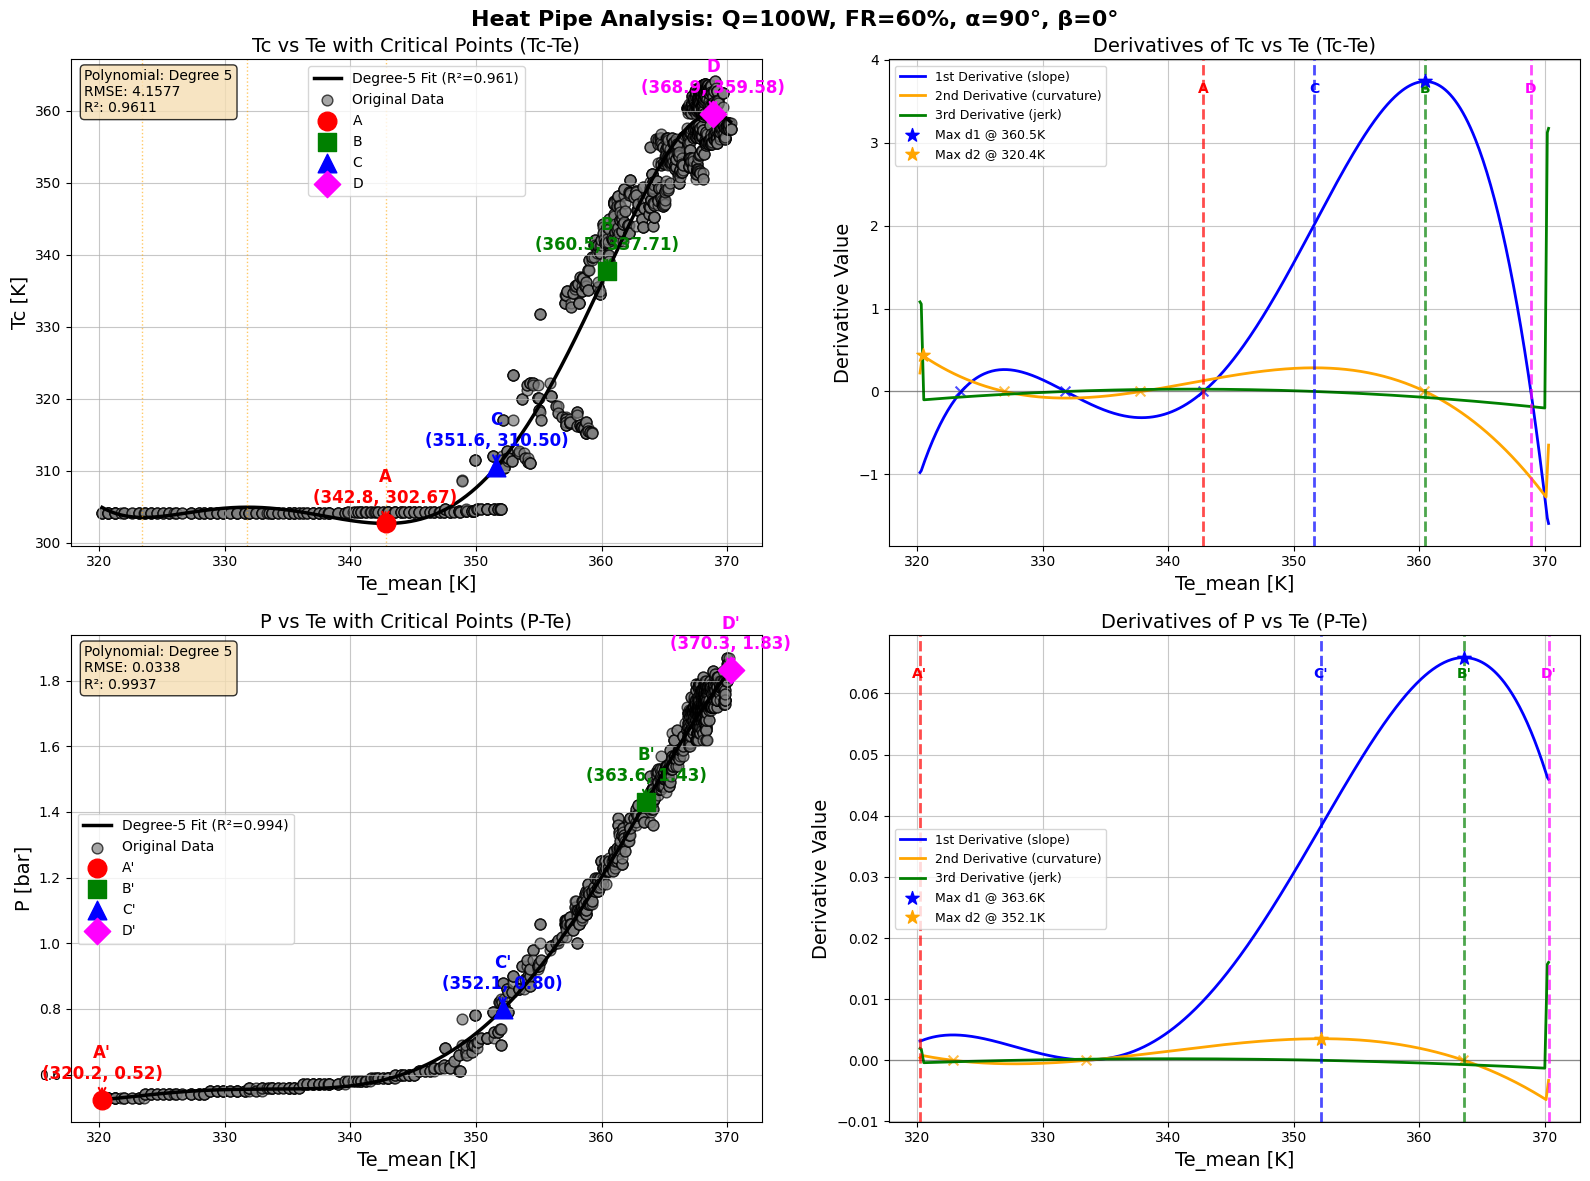


COMPREHENSIVE CRITICAL POINTS SUMMARY WITH VALIDATION

Tc vs Te (Temperature Analysis):
-------------------------------

Point A: Te = 342.8K, Tc = 302.666 K
  Derivatives: d1=-0.0018, d2=0.1310, d3=0.0274

Point B: Te = 360.5K, Tc = 337.711 K
  Derivatives: d1=3.7377, d2=-0.0002, d3=-0.0720
  📈 Condition Check: d1 efficiency = 100.0% of max, |d2| = 0.0002
  ✅ EXCELLENT: Optimal steep slope with minimal curvature

Point C: Te = 351.6K, Tc = 310.505 K
  Derivatives: d1=2.0132, d2=0.2849, d3=-0.0000
  📊 Condition Check: d2 efficiency = 100.0% of max, |d3| = 0.0000
  ✅ EXCELLENT: Maximum curvature with stable rate

Point D: Te = 368.9K, Tc = 359.584 K
  Derivatives: d1=-0.0059, d2=-1.0427, d3=-0.1821

🎯 Reference Global Maxima:
  Maximum slope: Te = 360.5K (d1 = 3.7377)
  Maximum curvature: Te = 320.4K (d2 = 0.4335)

📍 Point Positioning Analysis:
  Point B vs max d1 location: ΔTe = 0.0K
  Point C vs max d2 location: ΔTe = 31.2K
  ✅ Point B closely aligned with maximum slope
  ❌ Point C s

In [4]:
# Example usage function
def run_analysis_example():
    """Example of how to use the analysis function"""
    
    # Example parameters
    csv_path = 'database.csv'
    Q, FR, alpha, beta = 100, 60, 90, 0
    te_min, te_max = 320, 390
    point_A_Te = None  # User-defined A point, or None for automatic
    
    # Run analysis
    results = analyze_heat_pipe_data(
        csv_path=csv_path,
        Q=Q, FR=FR, alpha=alpha, beta=beta,
        te_min=te_min, te_max=te_max,
        point_A_Te=point_A_Te,
        poly_deg=5,
        outlier_threshold=2.5
    )
    
    return results

# Uncomment the line below to run the example
results = run_analysis_example()

Analysis for Q=120W, FR=60%, α=90°, β=0°
Te range: 320-360K
Data points before outlier removal: 616
Data points after Tc outlier removal: 616
Data points after P outlier removal: 616

POLYNOMIAL DEGREE OPTIMIZATION

📌 Using fixed polynomial degree for Tc vs Te: 15

🔍 Analyzing Tc vs Te relationship:
  Data points: 616
  Polynomial degree: 15
  📊 Fit Quality: RMSE = 6.5459, R² = 0.8705
  ✅ Good fit: Acceptable R² (0.870)

CRITICAL POINTS ANALYSIS
Point A: Te=320.1K, Y=301.391
  d1=5.9693, d2=-2.7724, d3=-16.5750
  → Minimum value point (automatic selection)
Point B: Te=357.2K, Y=330.033
  d1=8.8105, d2=-0.0256, d3=-1.9156
  → Maximum slope point
  → d1 achievement: 100.0% of global max (rank: 100.0%)
  → |d2| minimization: 0.0256 (rank from bottom: 3.9%)
  → Combined score: -0.699
  → Physical interpretation: Optimal transition point (steep slope, low curvature)
Point C: Te=354.7K, Y=311.464
  d1=5.3430, d2=2.0195, d3=0.0112
  → Maximum curvature point
  → d2 achievement: 100.0% of glob

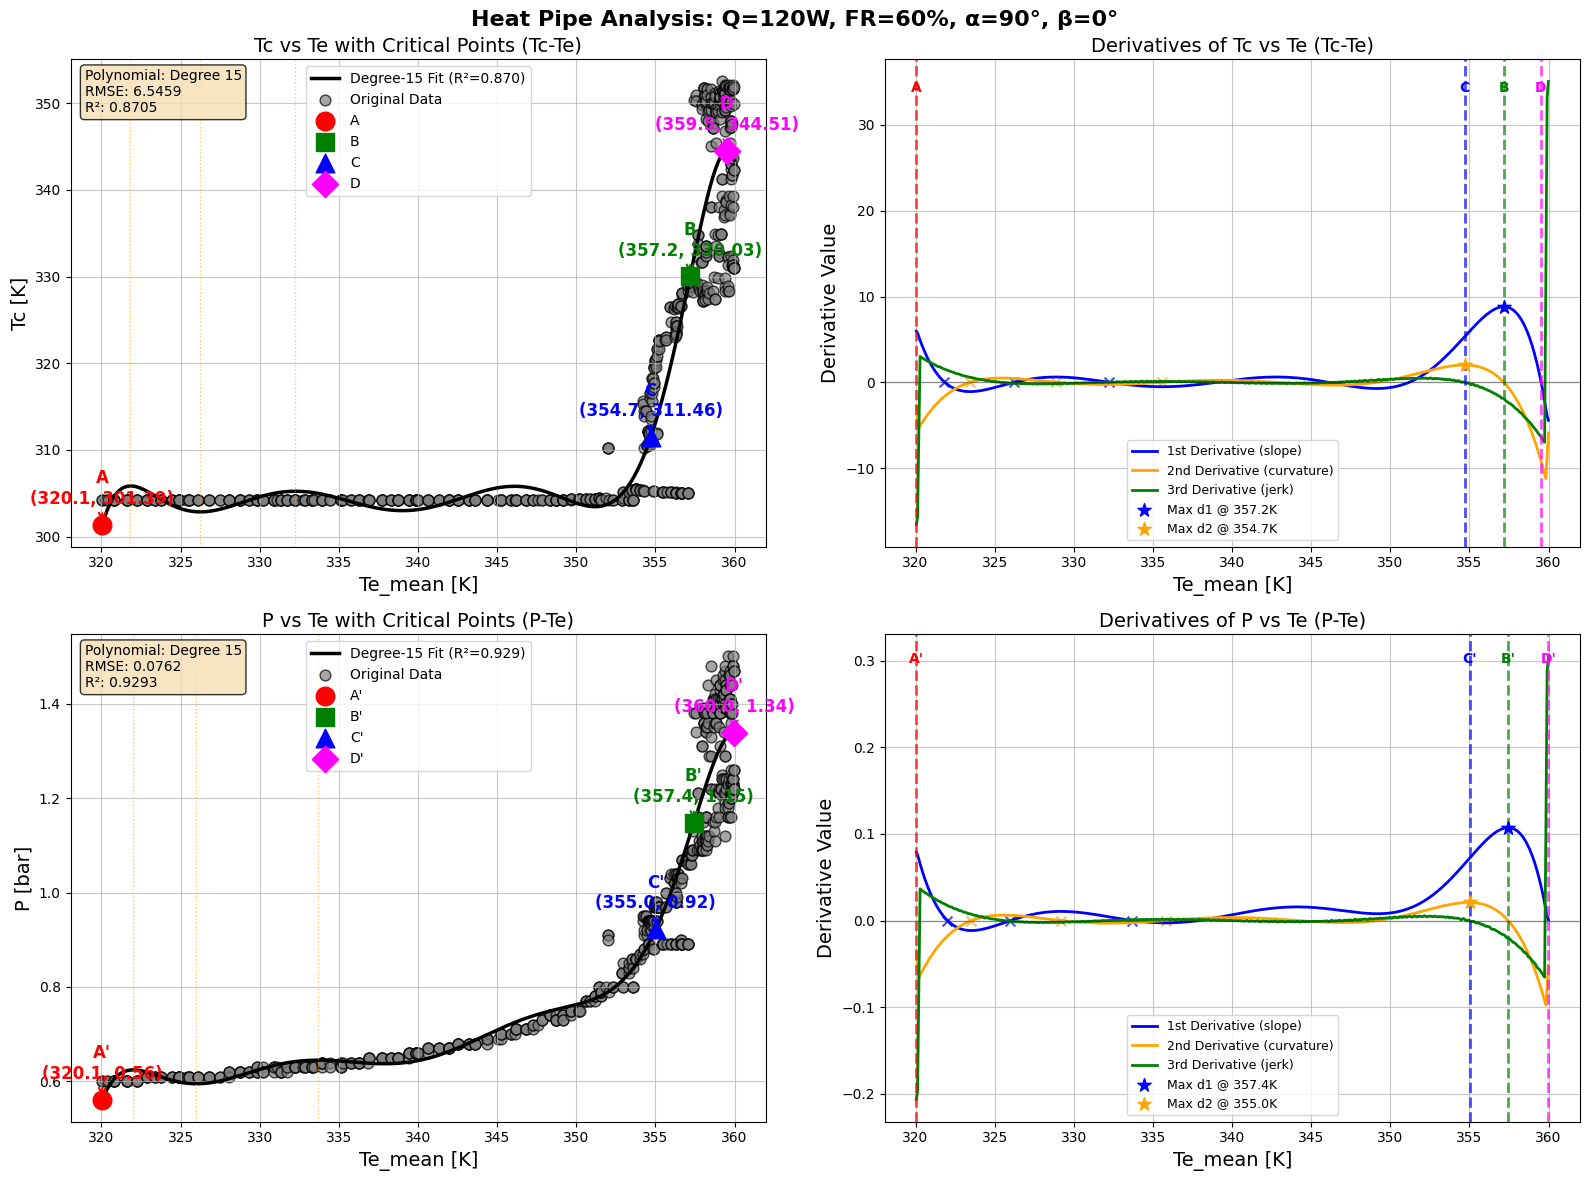


COMPREHENSIVE CRITICAL POINTS SUMMARY WITH VALIDATION

Tc vs Te (Temperature Analysis):
-------------------------------

Point A: Te = 320.1K, Tc = 301.391 K
  Derivatives: d1=5.9693, d2=-2.7724, d3=-16.5750

Point B: Te = 357.2K, Tc = 330.033 K
  Derivatives: d1=8.8105, d2=-0.0256, d3=-1.9156
  📈 Condition Check: d1 efficiency = 100.0% of max, |d2| = 0.0256
  ✅ EXCELLENT: Optimal steep slope with minimal curvature

Point C: Te = 354.7K, Tc = 311.464 K
  Derivatives: d1=5.3430, d2=2.0195, d3=0.0112
  📊 Condition Check: d2 efficiency = 100.0% of max, |d3| = 0.0112
  ✅ EXCELLENT: Maximum curvature with stable rate

Point D: Te = 359.5K, Tc = 344.510 K
  Derivatives: d1=0.2067, d2=-9.0636, d3=-6.3179

🎯 Reference Global Maxima:
  Maximum slope: Te = 357.2K (d1 = 8.8105)
  Maximum curvature: Te = 354.7K (d2 = 2.0195)

📍 Point Positioning Analysis:
  Point B vs max d1 location: ΔTe = 0.0K
  Point C vs max d2 location: ΔTe = 0.0K
  ✅ Point B closely aligned with maximum slope
  ✅ Point C cl

In [18]:
# Example usage function
def run_analysis_example():
    """Example of how to use the analysis function"""
    
    # Example parameters
    csv_path = 'database.csv'
    Q, FR, alpha, beta = 120, 60, 90, 0
    te_min, te_max = 320, 360
    point_A_Te = None  # User-defined A point, or None for automatic
    
    # Run analysis
    results = analyze_heat_pipe_data(
        csv_path=csv_path,
        Q=Q, FR=FR, alpha=alpha, beta=beta,
        te_min=te_min, te_max=te_max,
        point_A_Te=point_A_Te,
        poly_deg=15,
        outlier_threshold=2.5
    )
    
    return results

# Uncomment the line below to run the example
results = run_analysis_example()

Analysis for Q=60W, FR=60%, α=90°, β=0°
Te range: 320-390K
Data points before outlier removal: 1629
Data points after Tc outlier removal: 1629
Data points after P outlier removal: 1629

POLYNOMIAL DEGREE OPTIMIZATION

📌 Using fixed polynomial degree for Tc vs Te: 30

🔍 Analyzing Tc vs Te relationship:
  Data points: 1629
  Polynomial degree: 30
  📊 Fit Quality: RMSE = 1.6721, R² = 0.8740
  ✅ Good fit: Acceptable R² (0.874)

CRITICAL POINTS ANALYSIS
Point A: Te=321.4K, Y=305.721
  d1=-0.0204, d2=0.6784, d3=-0.8188
  → Minimum value point (automatic selection)
Point B: Te=352.8K, Y=313.867
  d1=2.9460, d2=0.0177, d3=-1.3690
  → Maximum slope point
  → d1 achievement: 100.0% of global max (rank: 100.0%)
  → |d2| minimization: 0.0177 (rank from bottom: 8.6%)
  → Combined score: -0.699
  → Physical interpretation: Optimal transition point (steep slope, low curvature)
Point C: Te=351.2K, Y=309.750
  d1=1.8956, d2=0.9097, d3=0.0020
  → Maximum curvature point
  → d2 achievement: 100.0% of glo

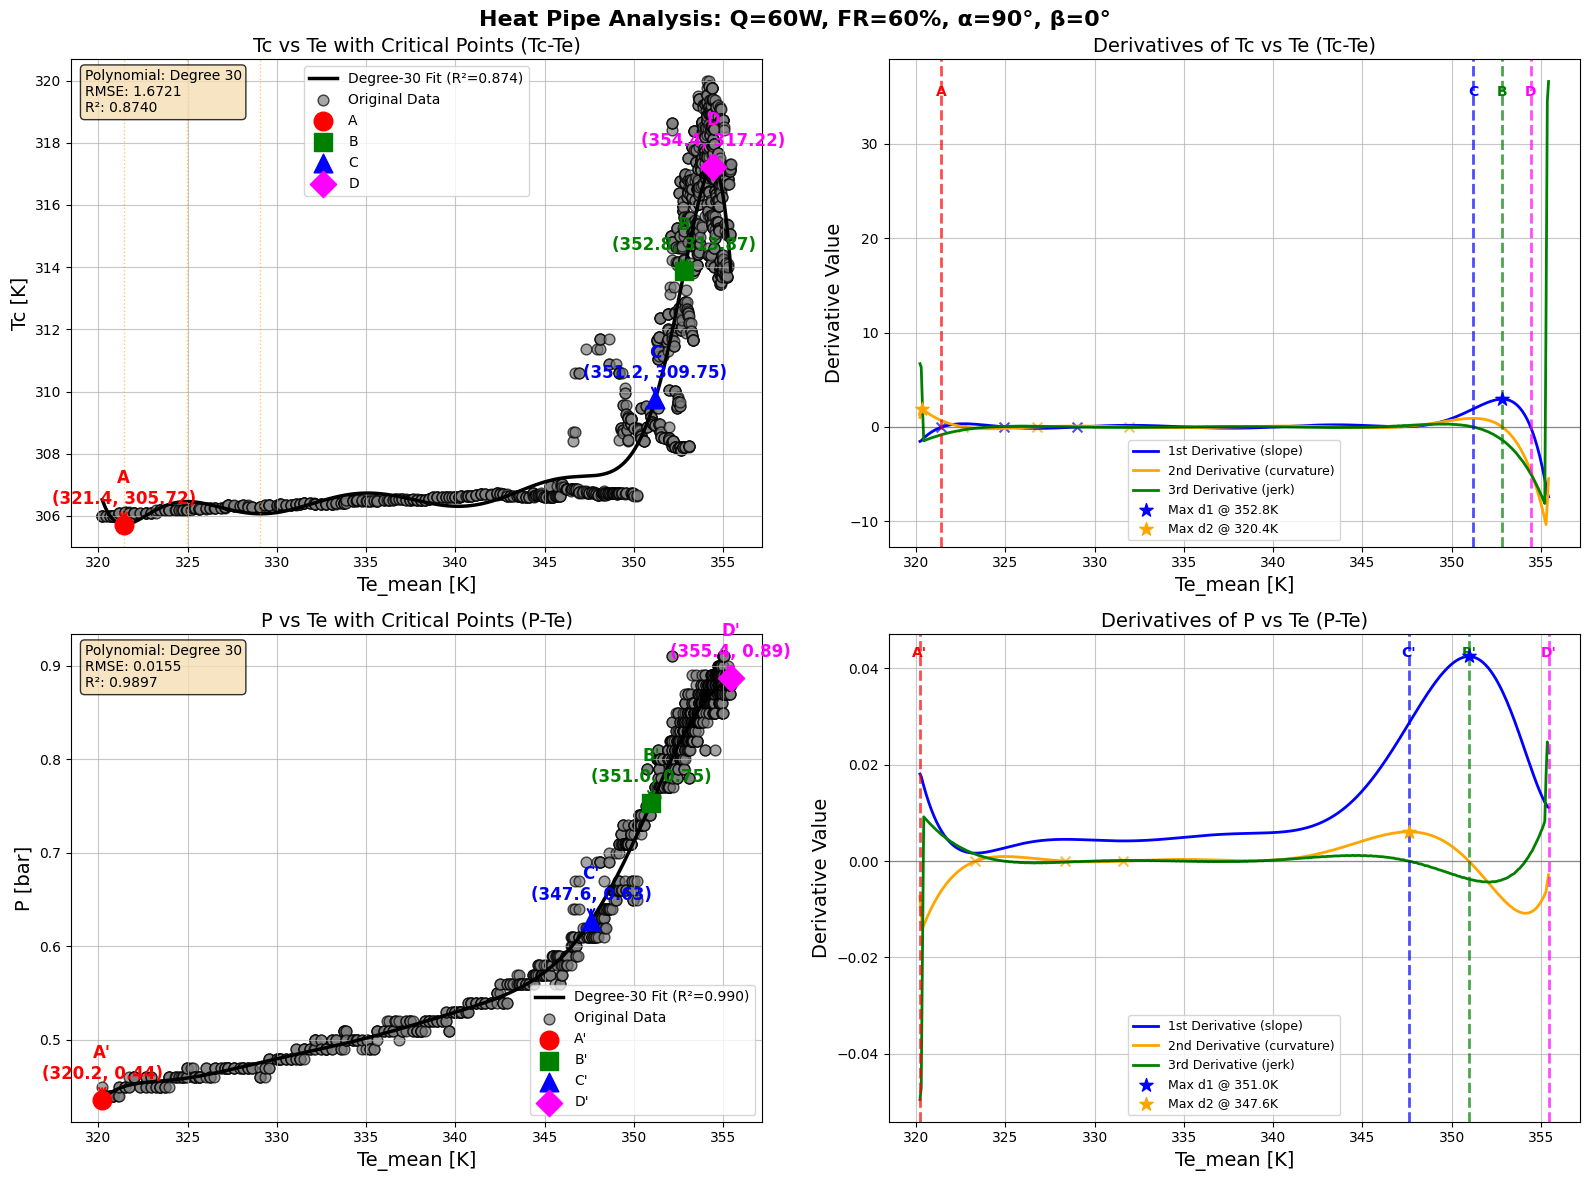


COMPREHENSIVE CRITICAL POINTS SUMMARY WITH VALIDATION

Tc vs Te (Temperature Analysis):
-------------------------------

Point A: Te = 321.4K, Tc = 305.721 K
  Derivatives: d1=-0.0204, d2=0.6784, d3=-0.8188

Point B: Te = 352.8K, Tc = 313.867 K
  Derivatives: d1=2.9460, d2=0.0177, d3=-1.3690
  📈 Condition Check: d1 efficiency = 100.0% of max, |d2| = 0.0177
  ✅ EXCELLENT: Optimal steep slope with minimal curvature

Point C: Te = 351.2K, Tc = 309.750 K
  Derivatives: d1=1.8956, d2=0.9097, d3=0.0020
  📊 Condition Check: d2 efficiency = 100.0% of max, |d3| = 0.0020
  ✅ EXCELLENT: Maximum curvature with stable rate

Point D: Te = 354.4K, Tc = 317.217 K
  Derivatives: d1=-0.0852, d2=-4.7336, d3=-5.0113

🎯 Reference Global Maxima:
  Maximum slope: Te = 352.8K (d1 = 2.9460)
  Maximum curvature: Te = 320.4K (d2 = 1.8941)

📍 Point Positioning Analysis:
  Point B vs max d1 location: ΔTe = 0.0K
  Point C vs max d2 location: ΔTe = 30.8K
  ✅ Point B closely aligned with maximum slope
  ❌ Point C si

In [6]:
# Test the updated analysis with better critical point identification
results = analyze_heat_pipe_data(
    csv_path='database.csv',
    Q=60, FR=60, alpha=90, beta=0,
    te_min=320, te_max=390,
    point_A_Te=None,  # Let it find minimum automatically
    poly_deg=30,
    outlier_threshold=2.5
)

🚀 Testing Enhanced Heat Pipe Analysis with Auto Polynomial Optimization
Analysis for Q=60W, FR=60%, α=90°, β=0°
Te range: 320-390K
Data points before outlier removal: 1629
Data points after Tc outlier removal: 1629
Data points after P outlier removal: 1629

POLYNOMIAL DEGREE OPTIMIZATION

🔧 Optimizing polynomial degree for Tc vs Te:
🔍 Optimizing polynomial degree (testing degrees 5-15)...
  📊 Degree optimization results:
    • Best RMSE: degree 15 (RMSE: 144.1637)
    • Best AIC: degree 5 (AIC: 2225.14)
    • Best BIC: degree 5 (BIC: 2257.51)
    • 🎯 Optimal (composite): degree 15 (RMSE: 144.1637, R²: 0.8237)
    ⚠️ High degree (15) detected - potential overfitting risk

🔍 Analyzing Tc vs Te relationship:
  Data points: 1629
  Polynomial degree: 15
  📊 Fit Quality: RMSE = 1.7728, R² = 0.8584
  ✅ Good fit: Acceptable R² (0.858)

CRITICAL POINTS ANALYSIS
Point A: Te=330.0K, Y=306.495
  d1=-0.3128, d2=-0.0170, d3=0.0751
  → User-defined starting point (Te=330K)
Point B: Te=352.3K, Y=312.8

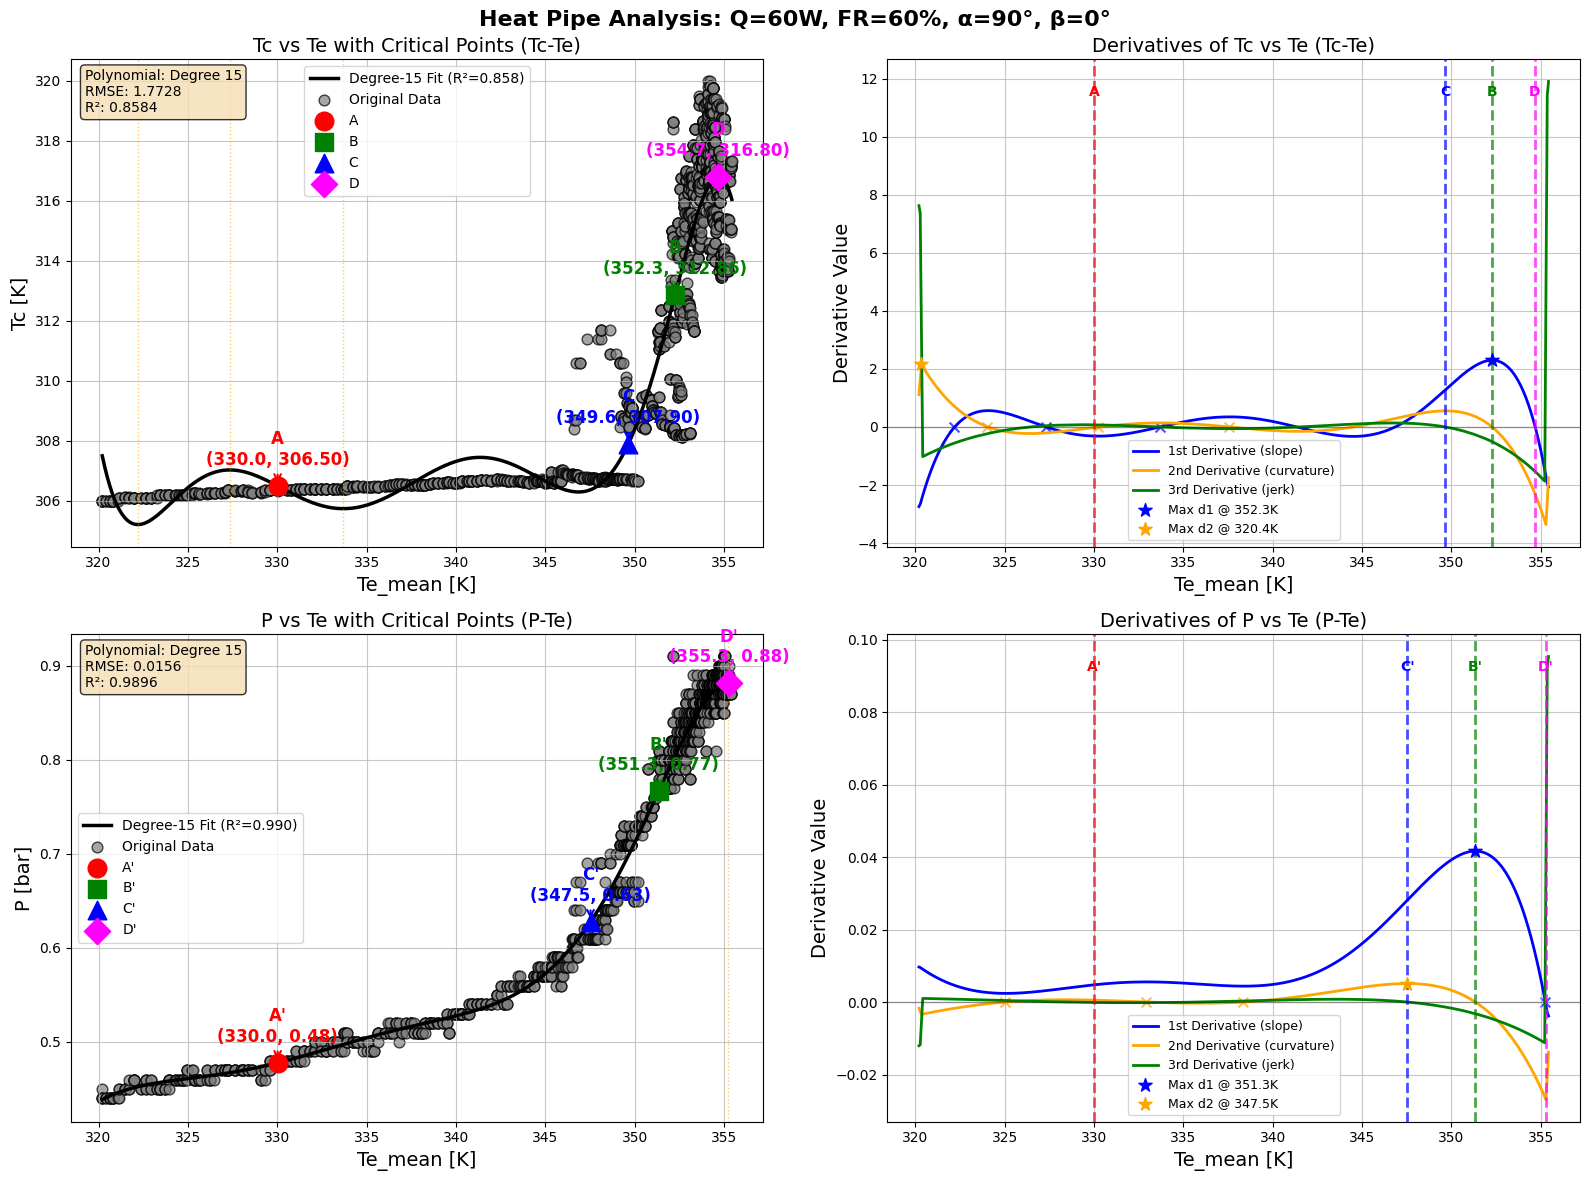


COMPREHENSIVE CRITICAL POINTS SUMMARY WITH VALIDATION

Tc vs Te (Temperature Analysis):
-------------------------------

Point A: Te = 330.0K, Tc = 306.495 K
  Derivatives: d1=-0.3128, d2=-0.0170, d3=0.0751

Point B: Te = 352.3K, Tc = 312.863 K
  Derivatives: d1=2.3015, d2=0.0126, d3=-0.5010
  📈 Condition Check: d1 efficiency = 100.0% of max, |d2| = 0.0126
  ✅ EXCELLENT: Optimal steep slope with minimal curvature

Point C: Te = 349.6K, Tc = 307.896 K
  Derivatives: d1=1.2743, d2=0.5568, d3=0.0022
  📊 Condition Check: d2 efficiency = 100.0% of max, |d3| = 0.0022
  ✅ EXCELLENT: Maximum curvature with stable rate

Point D: Te = 354.7K, Tc = 316.798 K
  Derivatives: d1=0.0714, d2=-2.2773, d3=-1.5196

🎯 Reference Global Maxima:
  Maximum slope: Te = 352.3K (d1 = 2.3015)
  Maximum curvature: Te = 320.4K (d2 = 2.1546)

📍 Point Positioning Analysis:
  Point B vs max d1 location: ΔTe = 0.0K
  Point C vs max d2 location: ΔTe = 29.3K
  ✅ Point B closely aligned with maximum slope
  ❌ Point C sig

In [14]:
# Test the enhanced analysis with automatic polynomial degree optimization
print("🚀 Testing Enhanced Heat Pipe Analysis with Auto Polynomial Optimization")
print("="*70)

results_auto = analyze_heat_pipe_data(
    csv_path='database.csv',
    Q=60, FR=60, alpha=90, beta=0,
    te_min=320, te_max=390,
    point_A_Te=330,  # Let it find minimum automatically
    poly_deg='auto',  # 🔥 NEW: Automatic polynomial degree optimization
    outlier_threshold=2.5,
    max_poly_deg=15,  # Maximum degree to test
    min_poly_deg=5, # Let it find minimum automatically
)